# 03 — Artistas

**O que vamos olhar e por quê.** O artista é um dos três tipos de nó do grafo. Para escolher boas features e arestas, precisamos saber: quantos artistas distintos aparecem, qual a distribuição de hits por artista, quão colaborativos são, e quantos gêneros cada um cobre. Esse mapa orienta tanto a feature inicial do nó `artist` quanto a aresta `artist↔artist` (que vamos confirmar no notebook 04 com a rede do MGD+).

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if ROOT.name == "exploration":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
from music_diffusion_gnn.data.loaders import load_artists

artists = load_artists()  # carrega br-artists-all_time.csv e parse genres → genres_list
print('shape:', artists.shape)
print('colunas:', list(artists.columns))
artists.head(3)

shape: (1701, 7)
colunas: ['artist_id', 'name', 'genres', 'years_on_charts', 'num_hits', 'num_collab_hits', 'genres_list']


,artist_id,name,genres,years_on_charts,num_hits,num_collab_hits,genres_list
0,1yR65psqiazQpeM79CcGh8,Marília Mendonça,"['arrocha', 'sertanejo', 'sertanejo universita...","[2017, 2018, 2019, 2020, 2021, 2022]",140,78,"[arrocha, sertanejo, sertanejo universitario]"
1,3p7PcrEHaaKLJnPUGOtRlT,Henrique & Juliano,"['agronejo', 'arrocha', 'sertanejo', 'sertanej...","[2017, 2018, 2019, 2020, 2021, 2022]",117,19,"[agronejo, arrocha, sertanejo, sertanejo unive..."
2,7MiDcPa6UiV3In7lIM71IN,Gusttavo Lima,"['agronejo', 'arrocha', 'sertanejo', 'sertanej...","[2017, 2018, 2019, 2020, 2021, 2022]",106,28,"[agronejo, arrocha, sertanejo, sertanejo unive..."


## 1) Quantos hits por artista?

`num_hits` = total de músicas distintas do artista que estiveram no Top 200 BR no período. Esperado: cauda longa (poucos artistas com muitos hits, muitos com 1-2).

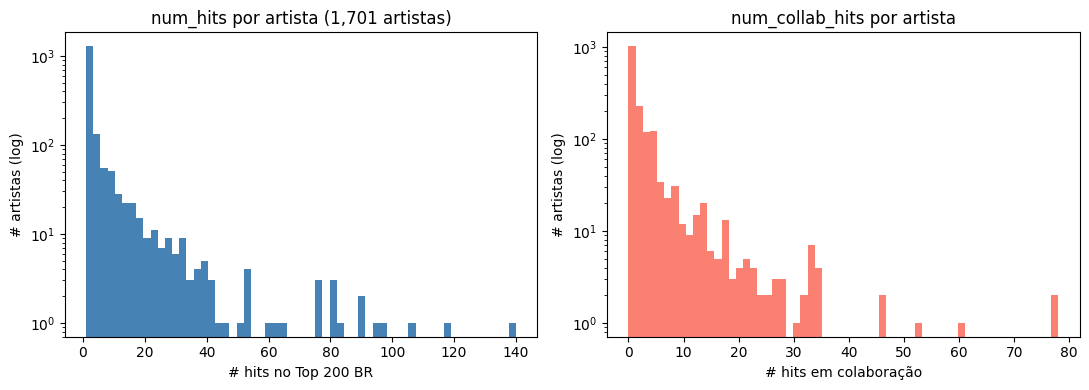


Quantis:
       num_hits  num_collab_hits
count    1701.0           1701.0
mean        4.8              3.1
std        10.9              5.9
min         1.0              0.0
50%         1.0              1.0
75%         3.0              3.0
90%        11.0              7.0
99%        54.0             32.0
max       140.0             78.0


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(artists['num_hits'], bins=60, color='steelblue')
axes[0].set_yscale('log')
axes[0].set_title(f'num_hits por artista ({len(artists):,} artistas)')
axes[0].set_xlabel('# hits no Top 200 BR'); axes[0].set_ylabel('# artistas (log)')

axes[1].hist(artists['num_collab_hits'], bins=60, color='salmon')
axes[1].set_yscale('log')
axes[1].set_title('num_collab_hits por artista')
axes[1].set_xlabel('# hits em colaboração'); axes[1].set_ylabel('# artistas (log)')

plt.tight_layout(); plt.show()

print('\nQuantis:')
print(artists[['num_hits', 'num_collab_hits']].describe(percentiles=[0.5, 0.75, 0.9, 0.99]).round(1))

**Leitura:** distribuição power-law clássica. A maioria dos artistas tem ≤ 2 hits. Os artistas no P99 são o que dominam o sinal — e provavelmente também são hubs no grafo de colaboração.

## 2) Top artistas e propensão a colaborar

In [3]:
top = artists.nlargest(20, 'num_hits')[['name', 'num_hits', 'num_collab_hits']].copy()
top['% colab'] = (top['num_collab_hits'] / top['num_hits'] * 100).round(1)
print('Top 20 artistas por # hits:')
print(top.to_string(index=False))

Top 20 artistas por # hits:
                  name  num_hits  num_collab_hits  % colab
      Marília Mendonça       140               78     55.7
    Henrique & Juliano       117               19     16.2
         Gusttavo Lima       106               28     26.4
          Taylor Swift        98               13     13.3
                Anitta        95               77     81.1
                   BTS        91               17     18.7
       Matheus & Kauan        90               33     36.7
        Jorge & Mateus        83               25     30.1
   Zé Neto & Cristiano        82               14     17.1
      Maiara & Maraisa        81               60     74.1
        Wesley Safadão        80               46     57.5
Os Barões Da Pisadinha        77               33     42.9
         Ariana Grande        76               30     39.5
         Pabllo Vittar        76               46     60.5
                 Drake        65               26     40.0
            The Weeknd      

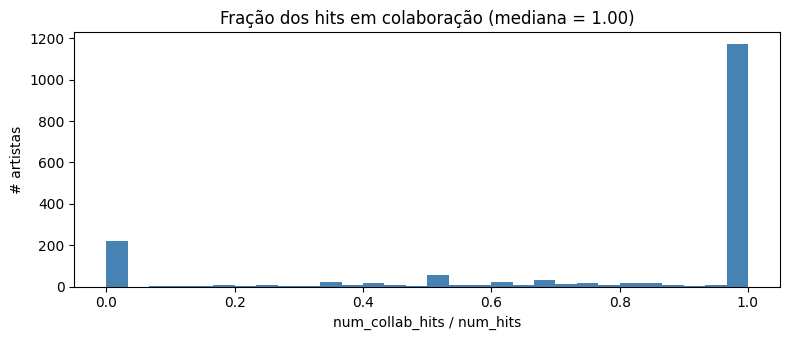

In [4]:
# Razão colab / total — quão colaborativo é cada artista?
ratio = (artists['num_collab_hits'] / artists['num_hits'].replace(0, np.nan)).dropna()
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(ratio, bins=30, color='steelblue')
ax.set_title(f'Fração dos hits em colaboração (mediana = {ratio.median():.2f})')
ax.set_xlabel('num_collab_hits / num_hits'); ax.set_ylabel('# artistas')
plt.tight_layout(); plt.show()

**Leitura:** se a mediana for >0, é sinal de que colaboração é parte central do mercado BR (notório em sertanejo, funk, trap). É exatamente o tipo de aresta que um GNN heterogêneo explora bem.

## 3) Multi-rótulo: quantos gêneros por artista?

Cada artista tem uma **lista** de gêneros (Spotify atribui múltiplos). Isso impacta a aresta `artist→genre`: não é uma escolha única, é multi-edge.

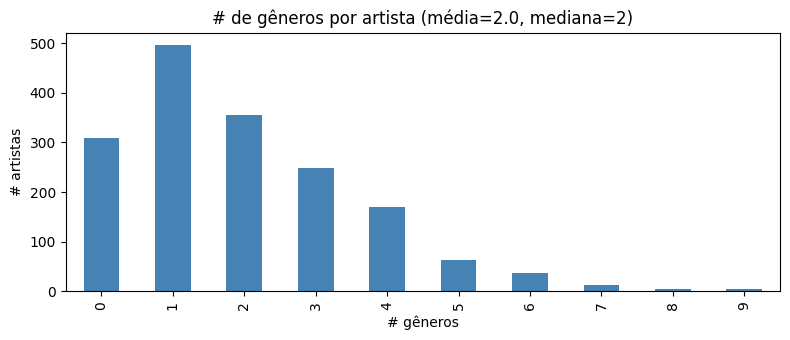


Total de pares (artista, gênero): 3,344
Gêneros únicos: 530

Top 15 gêneros por # artistas:
funk carioca               137
pop                        135
funk mtg                    95
sertanejo universitario     92
rap                         77
arrocha                     69
sertanejo                   65
sertanejo pop               65
trap brasileiro             61
brazilian hip hop           59
funk paulista               52
trap                        49
pop dance                   47
pop rap                     46
pop nacional                45


In [5]:
n_genres = artists['genres_list'].apply(len)
fig, ax = plt.subplots(figsize=(8, 3.5))
n_genres.clip(upper=15).value_counts().sort_index().plot.bar(ax=ax, color='steelblue')
ax.set_title(f'# de gêneros por artista (média={n_genres.mean():.1f}, mediana={int(n_genres.median())})')
ax.set_xlabel('# gêneros'); ax.set_ylabel('# artistas')
plt.tight_layout(); plt.show()

# Quantos gêneros únicos no total?
all_genres = pd.Series([g for lst in artists['genres_list'] for g in lst])
print(f'\nTotal de pares (artista, gênero): {len(all_genres):,}')
print(f'Gêneros únicos: {all_genres.nunique():,}')
print('\nTop 15 gêneros por # artistas:')
print(all_genres.value_counts().head(15).to_string())

**Leitura:** o número de gêneros únicos define o tamanho do conjunto de nós `genre`. Os top gêneros (provavelmente sertanejo universitario, funk carioca, pagode, mpb, pop, etc.) são os hubs naturais do subgrafo gênero.

## Insight para o GNN

1. **Features de nó `artist`:** `num_hits` (log-transformada), `num_collab_hits` (idem), fração de colaboração, anos ativos (`years_on_charts`). Vetor curto mas informativo.
2. **Aresta `artist→genre`:** multi-rótulo. O grafo deve aceitar múltiplos pares (artist, genre) por artista — não escolher um "gênero principal".
3. **Aresta `artist↔artist`:** já temos a rede pronta no MGD+ (próximo notebook). O peso é o número de músicas em colaboração. Faz sentido **podar arestas com peso=1** se a rede ficar densa demais.
4. **Cauda longa de artistas:** muitos artistas com 1 hit isolado e zero colaborações. Esses têm grau muito baixo no grafo — message passing vai depender mais das features iniciais do nó do que da vizinhança.